# <B><U><I>mxmh_recommendation_intelligence</U> ----</B></I>

In [1]:
# IGNOR WARNING --

import warnings
warnings.filterwarnings("ignore")

# IMPORTING ALL NECESSARY LIBRARIES --

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [2]:

# PATH SETUP --

CURRENT_DIR = Path.cwd()              # notebooks folder ke andar current notebook location
NOTEBOOKS_DIR = CURRENT_DIR.parent    # notebooks
PREPROCESSED_DIR = NOTEBOOKS_DIR / "preprocessed"
OUTPUT_DIR = NOTEBOOKS_DIR / "recommendation_outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Preprocessed dir:", PREPROCESSED_DIR)
print("Output dir:", OUTPUT_DIR)

Preprocessed dir: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\preprocessed
Output dir: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\recommendation_outputs


In [3]:

# LOAD DATA --

file_path = PREPROCESSED_DIR / "mxmh_feature_engineered.csv"

df = pd.read_csv(file_path)

print("Loaded shape:", df.shape)
df.head()

Loaded shape: (736, 42)


,age,streaming_service,hours_per_day,while_working,instrumentalist,composer,fav_genre,exploratory,foreign_languages,bpm,freq_classical,freq_country,freq_edm,freq_folk,freq_gospel,freq_hip_hop,freq_jazz,freq_k_pop,freq_latin,freq_lofi,freq_metal,freq_pop,freq_rnb,freq_rap,freq_rock,freq_vgm,anxiety,depression,insomnia,ocd,music_effects,music_effects_label,mental_health_score,music_engagement_score,focus_listening_score,high_energy_score,calm_music_score,intense_music_score,genre_diversity_score,bpm_zone,mental_health_band,listening_band
0,18.0,spotify,3.0,1,1,1,latin,1,1,156.0,1,0,1,0,0,2,0,3,3,1,0,3,2,3,0,2,3.0,0.0,1.0,0.0,improve,2,1.00,6.0,5,9,2,3,21,high_bpm,low,moderate_listener
1,63.0,pandora,1.5,1,0,0,rock,1,0,119.0,2,0,0,1,2,1,3,1,2,1,0,2,2,1,3,1,7.0,2.0,2.0,1.0,improve,2,3.00,2.5,5,4,7,4,22,medium_bpm,moderate,low_listener
2,18.0,spotify,4.0,0,0,0,video game music,0,1,132.0,0,0,3,0,0,1,1,3,0,2,2,1,0,1,1,3,7.0,7.0,10.0,2.0,no effect,1,6.50,4.0,5,6,3,4,18,high_bpm,high,moderate_listener
3,61.0,youtube music,2.5,1,0,1,jazz,1,1,84.0,2,0,0,1,2,0,3,2,3,2,0,2,2,0,0,0,9.0,7.0,3.0,3.0,improve,2,5.50,4.5,5,2,8,0,19,low_bpm,moderate,moderate_listener
4,18.0,spotify,4.0,1,0,0,r&b,1,0,107.0,0,0,1,0,1,3,0,3,2,2,0,2,3,3,0,1,7.0,2.0,5.0,9.0,improve,2,5.75,5.0,4,9,2,3,21,medium_bpm,moderate,moderate_listener


In [4]:
print("Total columns:", len(df.columns))
print(df.columns.tolist())

Total columns: 42
['age', 'streaming_service', 'hours_per_day', 'while_working', 'instrumentalist', 'composer', 'fav_genre', 'exploratory', 'foreign_languages', 'bpm', 'freq_classical', 'freq_country', 'freq_edm', 'freq_folk', 'freq_gospel', 'freq_hip_hop', 'freq_jazz', 'freq_k_pop', 'freq_latin', 'freq_lofi', 'freq_metal', 'freq_pop', 'freq_rnb', 'freq_rap', 'freq_rock', 'freq_vgm', 'anxiety', 'depression', 'insomnia', 'ocd', 'music_effects', 'music_effects_label', 'mental_health_score', 'music_engagement_score', 'focus_listening_score', 'high_energy_score', 'calm_music_score', 'intense_music_score', 'genre_diversity_score', 'bpm_zone', 'mental_health_band', 'listening_band']


In [6]:
# TARGET DISTRIBUTION --

if "music_effects" in df.columns:
    print(df["music_effects"].value_counts(dropna=False))
else:
    print("music_effects column not found")

music_effects
improve      550
no effect    169
worsen        17
Name: count, dtype: int64


In [7]:
# ============================================================
# KEEP VALID MUSIC EFFECT CLASSES
# ============================================================

valid_classes = ["improve", "no effect", "worsen"]

df["music_effects"] = df["music_effects"].astype(str).str.strip().str.lower()
df = df[df["music_effects"].isin(valid_classes)].copy()

print("Shape after valid target filtering:", df.shape)
print(df["music_effects"].value_counts())

Shape after valid target filtering: (736, 42)
music_effects
improve      550
no effect    169
worsen        17
Name: count, dtype: int64


In [8]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
nulls

Series([], dtype: int64)

In [9]:

# LIGHT CLEANING FOR RECOMMENDATION ANALYSIS --

if "bpm" in df.columns:
    df["bpm"] = df["bpm"].fillna(df["bpm"].median())

if "age" in df.columns:
    df["age"] = df["age"].fillna(df["age"].median())

# fav_genre / service type / binary columns ke liye mode fill
for col in ["fav_genre", "streaming_service"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after basic fill:")
print(df.isnull().sum().sum())

Missing values after basic fill:
0


In [11]:

# RECOMMENDATION-ORIENTED DERIVED FEATURES --


# 1) Combined mental health burden
df["mh_total_score"] = (
    df["anxiety"] +
    df["depression"] +
    df["insomnia"] +
    df["ocd"]
)

# 2) Average mental health severity
df["mh_avg_score"] = df["mh_total_score"] / 4

# 3) Calm preference score
# low-energy / calm leaning genres ki frequency based rough signal
calm_cols = [
    "freq_classical",
    "freq_lofi",
    "freq_jazz"
]

existing_calm_cols = [c for c in calm_cols if c in df.columns]

if len(existing_calm_cols) > 0:
    df["calm_pref_score"] = df[existing_calm_cols].mean(axis=1)
else:
    df["calm_pref_score"] = 0

# 4) High-energy preference score
energy_cols = [
    "freq_edm",
    "freq_hip_hop",
    "freq_rap",
    "freq_metal"
]

existing_energy_cols = [c for c in energy_cols if c in df.columns]

if len(existing_energy_cols) > 0:
    df["high_energy_pref_score"] = df[existing_energy_cols].mean(axis=1)
else:
    df["high_energy_pref_score"] = 0

# 5) Total music engagement
engagement_cols = [
    "hours_per_day",
    "genre_diversity_score",
    "music_engagement_score"
]

existing_engagement_cols = [c for c in engagement_cols if c in df.columns]

if len(existing_engagement_cols) > 0:
    df["recommendation_engagement_score"] = df[existing_engagement_cols].mean(axis=1)
else:
    df["recommendation_engagement_score"] = df["hours_per_day"]


In [12]:

# CREATE USER BANDS --

def band_anxiety(x):
    if x <= 3:
        return "low"
    elif x <= 7:
        return "moderate"
    return "high"

def band_depression(x):
    if x <= 3:
        return "low"
    elif x <= 7:
        return "moderate"
    return "high"

def band_insomnia(x):
    if x <= 3:
        return "low"
    elif x <= 7:
        return "moderate"
    return "high"

def band_mh_avg(x):
    if x <= 3:
        return "low"
    elif x <= 6:
        return "moderate"
    return "high"

def band_listener(x):
    if x <= 2:
        return "low_listener"
    elif x <= 5:
        return "moderate_listener"
    return "heavy_listener"

def band_bpm(x):
    if x < 100:
        return "low_bpm"
    elif x <= 130:
        return "mid_bpm"
    return "high_bpm"

df["anxiety_band"] = df["anxiety"].apply(band_anxiety)
df["depression_band"] = df["depression"].apply(band_depression)
df["insomnia_band"] = df["insomnia"].apply(band_insomnia)
df["mh_band"] = df["mh_avg_score"].apply(band_mh_avg)
df["listener_band"] = df["hours_per_day"].apply(band_listener)
df["bpm_band"] = df["bpm"].apply(band_bpm)

# Combined high-risk flag
df["high_distress_flag"] = np.where(
    (df["anxiety"] >= 7) | (df["depression"] >= 7) | (df["insomnia"] >= 7),
    1,
    0
)

df[[
    "anxiety", "depression", "insomnia", "ocd",
    "mh_avg_score", "anxiety_band", "depression_band",
    "insomnia_band", "mh_band", "listener_band", "bpm_band"
]].head()

,anxiety,depression,insomnia,ocd,mh_avg_score,anxiety_band,depression_band,insomnia_band,mh_band,listener_band,bpm_band
0,3.0,0.0,1.0,0.0,1.00,low,low,low,low,moderate_listener,high_bpm
1,7.0,2.0,2.0,1.0,3.00,moderate,low,low,low,low_listener,mid_bpm
2,7.0,7.0,10.0,2.0,6.50,moderate,moderate,high,high,moderate_listener,high_bpm
3,9.0,7.0,3.0,3.0,5.50,high,moderate,low,moderate,moderate_listener,low_bpm
4,7.0,2.0,5.0,9.0,5.75,moderate,low,moderate,moderate,moderate_listener,mid_bpm


In [13]:
# DISTRIBUTION OF USER BAND --

print("Anxiety band distribution")
print(df["anxiety_band"].value_counts(), "\n")

print("Depression band distribution")
print(df["depression_band"].value_counts(), "\n")

print("Insomnia band distribution")
print(df["insomnia_band"].value_counts(), "\n")

print("Mental health band distribution")
print(df["mh_band"].value_counts(), "\n")

print("Listener band distribution")
print(df["listener_band"].value_counts(), "\n")

Anxiety band distribution
anxiety_band
moderate    320
high        239
low         177
Name: count, dtype: int64 

Depression band distribution
depression_band
moderate    300
low         276
high        160
Name: count, dtype: int64 

Insomnia band distribution
insomnia_band
low         387
moderate    239
high        110
Name: count, dtype: int64 

Mental health band distribution
mh_band
moderate    346
low         244
high        146
Name: count, dtype: int64 

Listener band distribution
listener_band
low_listener         338
moderate_listener    264
heavy_listener       134
Name: count, dtype: int64 



In [14]:
# TOP GENRE --

top_genres_overall = df["fav_genre"].value_counts().reset_index()
top_genres_overall.columns = ["fav_genre", "count"]
top_genres_overall.head(15)

,fav_genre,count
0,rock,188
1,pop,114
2,metal,88
3,classical,53
4,video game music,44
5,edm,37
6,hip hop,35
7,r&b,35
8,folk,30
9,k pop,26


In [15]:
# AMOUNG IMPROVED USERS --

improve_genres = (
    df[df["music_effects"] == "improve"]["fav_genre"]
    .value_counts()
    .reset_index()
)

improve_genres.columns = ["fav_genre", "improve_count"]
improve_genres.head(15)

,fav_genre,improve_count
0,rock,128
1,pop,85
2,metal,67
3,classical,39
4,edm,31
5,hip hop,31
6,video game music,26
7,r&b,26
8,folk,24
9,k pop,22


In [16]:
# AMOUNG WORSEN USERS --

worsen_genres = (
    df[df["music_effects"] == "worsen"]["fav_genre"]
    .value_counts()
    .reset_index()
)

worsen_genres.columns = ["fav_genre", "worsen_count"]
worsen_genres.head(15)

,fav_genre,worsen_count
0,rock,7
1,pop,4
2,video game music,4
3,classical,1
4,rap,1


In [17]:
# ANXIETY V/S GENRE

anxiety_genre_table = pd.crosstab(
    df["anxiety_band"],
    df["fav_genre"]
)

anxiety_genre_table

fav_genre,classical,country,edm,folk,gospel,hip hop,jazz,k pop,latin,lofi,metal,pop,r&b,rap,rock,video game music
anxiety_band,,,,,,,,,,,,,,,,
high,11,8,13,15,1,11,7,9,1,2,29,32,8,4,75,13
low,18,7,10,4,3,8,6,3,2,2,22,21,14,8,42,7
moderate,24,10,14,11,2,16,7,14,0,6,37,61,13,10,71,24


In [18]:
high_anxiety_genres = (
    df[df["anxiety_band"] == "high"]["fav_genre"]
    .value_counts()
    .reset_index()
)

high_anxiety_genres.columns = ["fav_genre", "high_anxiety_count"]
high_anxiety_genres.head(15)

,fav_genre,high_anxiety_count
0,rock,75
1,pop,32
2,metal,29
3,folk,15
4,edm,13
5,video game music,13
6,classical,11
7,hip hop,11
8,k pop,9
9,r&b,8


In [19]:
# INSOMNIA GENRE --

high_insomnia_genres = (
    df[df["insomnia_band"] == "high"]["fav_genre"]
    .value_counts()
    .reset_index()
)

high_insomnia_genres.columns = ["fav_genre", "high_insomnia_count"]
high_insomnia_genres.head(15)

,fav_genre,high_insomnia_count
0,rock,26
1,metal,21
2,pop,13
3,classical,10
4,video game music,9
5,edm,6
6,r&b,5
7,hip hop,4
8,jazz,3
9,folk,3


# <B>DISEASE + IMPROVED USER ----</B>

In [20]:
# HIGH ANXIETY + IMPROVED USER --

high_anxiety_improve_genres = (
    df[
        (df["anxiety_band"] == "high") &
        (df["music_effects"] == "improve")
    ]["fav_genre"]
    .value_counts()
    .reset_index()
)

high_anxiety_improve_genres.columns = ["fav_genre", "count"]
high_anxiety_improve_genres.head(15)

,fav_genre,count
0,rock,55
1,metal,25
2,pop,24
3,folk,13
4,edm,10
5,hip hop,10
6,classical,8
7,k pop,7
8,video game music,7
9,jazz,6


In [21]:
# INSOMNIA --

high_insomnia_improve_genres = (
    df[
        (df["insomnia_band"] == "high") &
        (df["music_effects"] == "improve")
    ]["fav_genre"]
    .value_counts()
    .reset_index()
)

high_insomnia_improve_genres.columns = ["fav_genre", "count"]
high_insomnia_improve_genres.head(15)

,fav_genre,count
0,rock,16
1,metal,15
2,pop,10
3,classical,9
4,edm,5
5,hip hop,3
6,jazz,3
7,video game music,3
8,folk,3
9,r&b,3


In [22]:
# HIGH DEPRESSION --

high_depression_improve_genres = (
    df[
        (df["depression_band"] == "high") &
        (df["music_effects"] == "improve")
    ]["fav_genre"]
    .value_counts()
    .reset_index()
)

high_depression_improve_genres.columns = ["fav_genre", "count"]
high_depression_improve_genres.head(15)

,fav_genre,count
0,rock,31
1,metal,21
2,pop,10
3,edm,9
4,classical,7
5,hip hop,7
6,lofi,6
7,folk,5
8,country,5
9,jazz,5


In [23]:
# BPM ANALYSIS --

bpm_effect_summary = (
    df.groupby("music_effects")["bpm"]
    .agg(["mean", "median", "min", "max", "count"])
    .round(2)
)

bpm_effect_summary

,mean,median,min,max,count
music_effects,,,,,
improve,122.59,120.0,4.0,218.0,550
no effect,123.59,120.0,66.0,220.0,169
worsen,118.71,120.0,60.0,180.0,17


In [24]:
# AVERAGE BY MUSIC EFFECT --

mh_effect_summary = (
    df.groupby("music_effects")[["anxiety", "depression", "insomnia", "ocd", "mh_avg_score"]]
    .mean()
    .round(2)
)

mh_effect_summary

,anxiety,depression,insomnia,ocd,mh_avg_score
music_effects,,,,,
improve,6.03,4.85,3.74,2.71,4.33
no effect,5.12,4.38,3.67,2.36,3.88
worsen,6.76,7.18,4.53,3.12,5.40


In [25]:
# CALM V/S ENERGY PREFERENCE --

pref_effect_summary = (
    df.groupby("music_effects")[["calm_pref_score", "high_energy_pref_score", "recommendation_engagement_score"]]
    .mean()
    .round(2)
)

pref_effect_summary

,calm_pref_score,high_energy_pref_score,recommendation_engagement_score
music_effects,,,
improve,1.16,1.26,9.17
no effect,1.09,1.17,8.41
worsen,1.02,1.28,7.96


# <I><B>IMPROVED RATE ----</B></I>

In [26]:
# IMROVED RATE BY FAV. GENRE --

genre_effect_counts = pd.crosstab(
    df["fav_genre"],
    df["music_effects"]
)

genre_effect_counts["total"] = genre_effect_counts.sum(axis=1)

for col in ["improve", "no effect", "worsen"]:
    if col not in genre_effect_counts.columns:
        genre_effect_counts[col] = 0

genre_effect_counts["improve_rate"] = (
    genre_effect_counts["improve"] / genre_effect_counts["total"]
).round(3)

genre_effect_counts["worsen_rate"] = (
    genre_effect_counts["worsen"] / genre_effect_counts["total"]
).round(3)

genre_effect_counts = genre_effect_counts.sort_values(
    by="improve_rate",
    ascending=False
)

genre_effect_counts.head(20)

music_effects,improve,no effect,worsen,total,improve_rate,worsen_rate
fav_genre,,,,,,
gospel,6,0,0,6,1.000,0.000
lofi,10,0,0,10,1.000,0.000
hip hop,31,4,0,35,0.886,0.000
k pop,22,4,0,26,0.846,0.000
edm,31,6,0,37,0.838,0.000
country,20,5,0,25,0.800,0.000
jazz,16,4,0,20,0.800,0.000
folk,24,6,0,30,0.800,0.000
rap,17,4,1,22,0.773,0.045


In [27]:
# BY BPM BAND --

bpm_band_effect = pd.crosstab(
    df["bpm_band"],
    df["music_effects"],
    normalize="index"
).round(3)

bpm_band_effect

music_effects,improve,no effect,worsen
bpm_band,,,
high_bpm,0.745,0.234,0.022
low_bpm,0.776,0.204,0.020
mid_bpm,0.737,0.238,0.025


In [28]:
# LISTENER BAND --

listener_effect = pd.crosstab(
    df["listener_band"],
    df["music_effects"],
    normalize="index"
).round(3)

listener_effect

music_effects,improve,no effect,worsen
listener_band,,,
heavy_listener,0.761,0.224,0.015
low_listener,0.710,0.257,0.033
moderate_listener,0.788,0.197,0.015


In [29]:
# ANXIETY BAND --

anxiety_effect = pd.crosstab(
    df["anxiety_band"],
    df["music_effects"],
    normalize="index"
).round(3)

anxiety_effect

music_effects,improve,no effect,worsen
anxiety_band,,,
high,0.766,0.205,0.029
low,0.638,0.345,0.017
moderate,0.794,0.184,0.022


In [30]:
# INSONIA BAND --

insomnia_effect = pd.crosstab(
    df["insomnia_band"],
    df["music_effects"],
    normalize="index"
).round(3)

insomnia_effect

music_effects,improve,no effect,worsen
insomnia_band,,,
high,0.718,0.255,0.027
low,0.739,0.243,0.018
moderate,0.774,0.197,0.029


In [31]:

# FINAL RECOMMENDATION RULE TABLE --


rule_rows = []

# Rule 1: high anxiety + improve
top3 = high_anxiety_improve_genres["fav_genre"].head(3).tolist()
rule_rows.append({
    "condition": "High anxiety users",
    "recommended_genres": ", ".join(top3) if len(top3) > 0 else "No strong pattern found",
    "reason": "Most common favourite genres among high-anxiety users whose music effect was Improve"
})

# Rule 2: high insomnia + improve
top3 = high_insomnia_improve_genres["fav_genre"].head(3).tolist()
rule_rows.append({
    "condition": "High insomnia users",
    "recommended_genres": ", ".join(top3) if len(top3) > 0 else "No strong pattern found",
    "reason": "Most common favourite genres among high-insomnia users whose music effect was Improve"
})

# Rule 3: high depression + improve
top3 = high_depression_improve_genres["fav_genre"].head(3).tolist()
rule_rows.append({
    "condition": "High depression users",
    "recommended_genres": ", ".join(top3) if len(top3) > 0 else "No strong pattern found",
    "reason": "Most common favourite genres among high-depression users whose music effect was Improve"
})

# Rule 4: overall highest improve rate genres
top_genres_improve = genre_effect_counts.head(5).index.tolist()
rule_rows.append({
    "condition": "Overall high positive music effect users",
    "recommended_genres": ", ".join(top_genres_improve),
    "reason": "Genres with highest improve rate across the dataset"
})

# Rule 5: BPM insight
best_bpm_band = bpm_band_effect["improve"].idxmax() if "improve" in bpm_band_effect.columns else "unknown"
rule_rows.append({
    "condition": "Best BPM listening band",
    "recommended_genres": best_bpm_band,
    "reason": "BPM band with highest Improve proportion"
})

recommendation_rules = pd.DataFrame(rule_rows)
recommendation_rules

,condition,recommended_genres,reason
0,High anxiety users,"rock, metal, pop",Most common favourite genres among high-anxiet...
1,High insomnia users,"rock, metal, pop",Most common favourite genres among high-insomn...
2,High depression users,"rock, metal, pop",Most common favourite genres among high-depres...
3,Overall high positive music effect users,"gospel, lofi, hip hop, k pop, edm",Genres with highest improve rate across the da...
4,Best BPM listening band,low_bpm,BPM band with highest Improve proportion


In [32]:
dashboard_reco_table = pd.DataFrame({
    "fav_genre": genre_effect_counts.index,
    "improve_count": genre_effect_counts["improve"].values,
    "no_effect_count": genre_effect_counts["no effect"].values,
    "worsen_count": genre_effect_counts["worsen"].values,
    "total_users": genre_effect_counts["total"].values,
    "improve_rate": genre_effect_counts["improve_rate"].values,
    "worsen_rate": genre_effect_counts["worsen_rate"].values
})

dashboard_reco_table.head(20)

,fav_genre,improve_count,no_effect_count,worsen_count,total_users,improve_rate,worsen_rate
0,gospel,6,0,0,6,1.000,0.000
1,lofi,10,0,0,10,1.000,0.000
2,hip hop,31,4,0,35,0.886,0.000
3,k pop,22,4,0,26,0.846,0.000
4,edm,31,6,0,37,0.838,0.000
5,country,20,5,0,25,0.800,0.000
6,jazz,16,4,0,20,0.800,0.000
7,folk,24,6,0,30,0.800,0.000
8,rap,17,4,1,22,0.773,0.045
9,metal,67,21,0,88,0.761,0.000


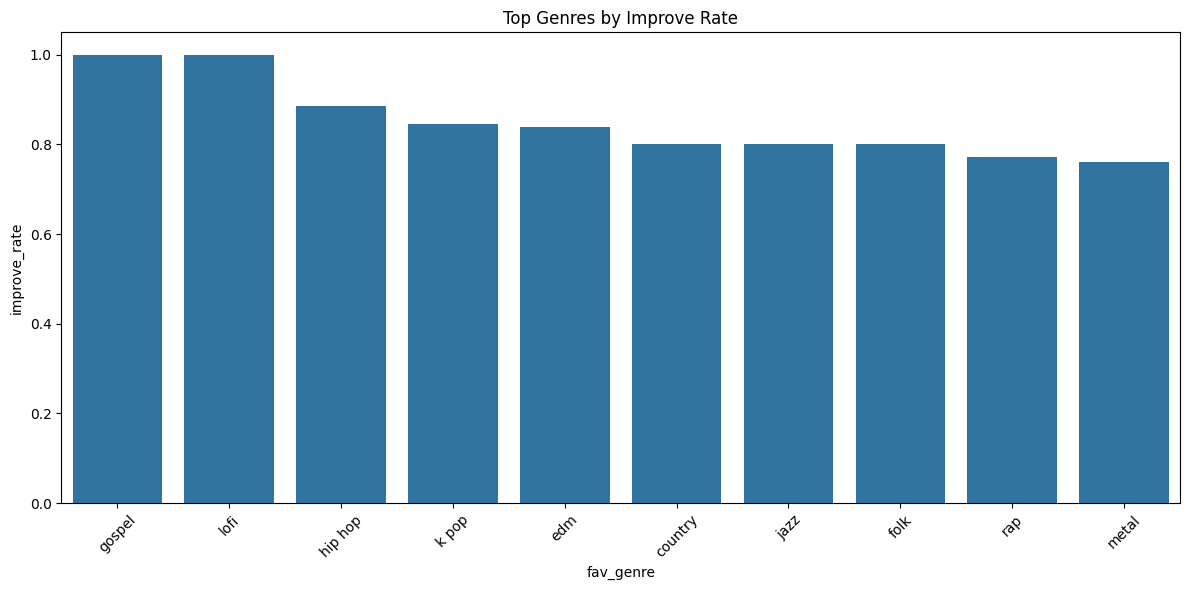

In [33]:
top_plot = dashboard_reco_table.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_plot, x="fav_genre", y="improve_rate")
plt.title("Top Genres by Improve Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

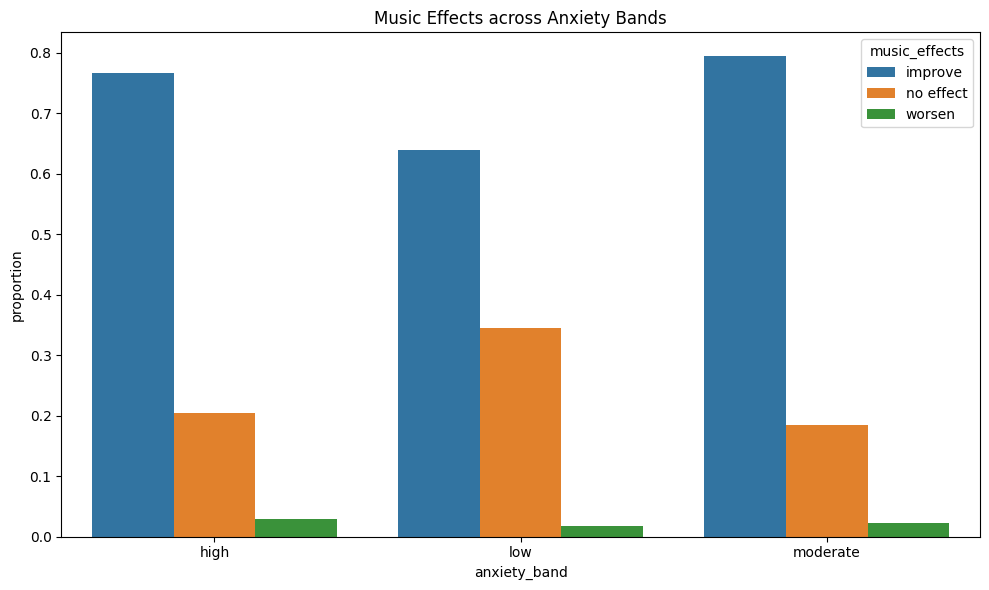

In [34]:
# ANXIETY BAND V/S MUSIC EFFECT --
anxiety_effect_plot = pd.crosstab(
    df["anxiety_band"],
    df["music_effects"],
    normalize="index"
).reset_index()

anxiety_effect_plot = anxiety_effect_plot.melt(
    id_vars="anxiety_band",
    var_name="music_effects",
    value_name="proportion"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=anxiety_effect_plot, x="anxiety_band", y="proportion", hue="music_effects")
plt.title("Music Effects across Anxiety Bands")
plt.tight_layout()
plt.show()

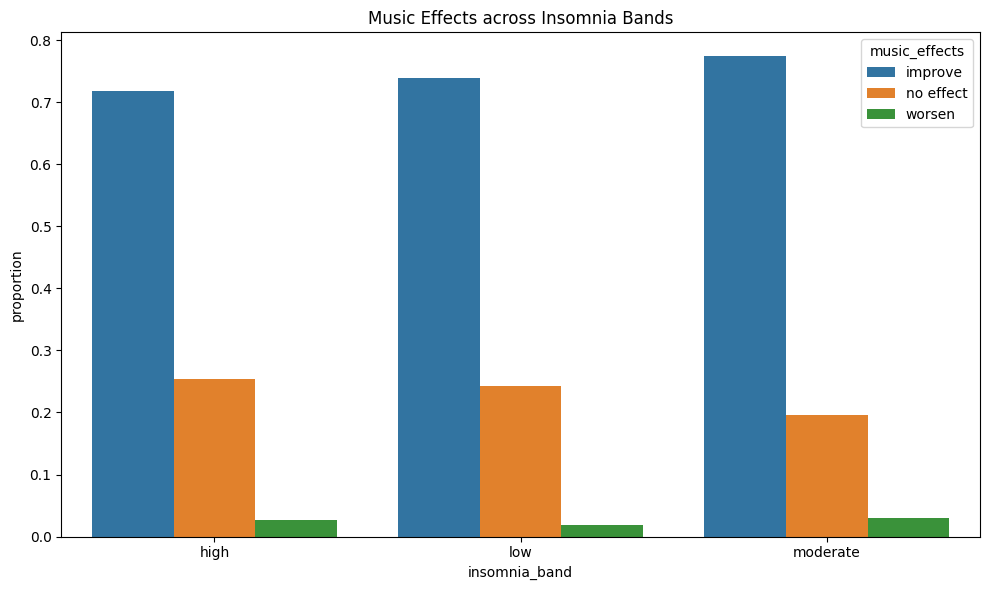

In [35]:
# INSOMNIA V/S MUSIC EFFECT --
insomnia_effect_plot = pd.crosstab(
    df["insomnia_band"],
    df["music_effects"],
    normalize="index"
).reset_index()

insomnia_effect_plot = insomnia_effect_plot.melt(
    id_vars="insomnia_band",
    var_name="music_effects",
    value_name="proportion"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=insomnia_effect_plot, x="insomnia_band", y="proportion", hue="music_effects")
plt.title("Music Effects across Insomnia Bands")
plt.tight_layout()
plt.show()

In [36]:

# SAVE RECOMMENDATION OUTPUTS --

recommendation_rules.to_csv(
    OUTPUT_DIR / "mxmh_recommendation_rules.csv",
    index=False
)

dashboard_reco_table.to_csv(
    OUTPUT_DIR / "mxmh_genre_improve_rates.csv",
    index=False
)

high_anxiety_improve_genres.to_csv(
    OUTPUT_DIR / "mxmh_high_anxiety_improve_genres.csv",
    index=False
)

high_insomnia_improve_genres.to_csv(
    OUTPUT_DIR / "mxmh_high_insomnia_improve_genres.csv",
    index=False
)

high_depression_improve_genres.to_csv(
    OUTPUT_DIR / "mxmh_high_depression_improve_genres.csv",
    index=False
)

bpm_effect_summary.to_csv(
    OUTPUT_DIR / "mxmh_bpm_effect_summary.csv"
)

mh_effect_summary.to_csv(
    OUTPUT_DIR / "mxmh_mental_health_effect_summary.csv"
)

pref_effect_summary.to_csv(
    OUTPUT_DIR / "mxmh_preference_effect_summary.csv"
)

print("MXMH recommendation intelligence outputs saved successfully.")
print("Saved in:", OUTPUT_DIR)

MXMH recommendation intelligence outputs saved successfully.
Saved in: c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\recommendation_outputs


In [41]:
# recommendation_rules
# dashboard_reco_table.head(15)
# high_anxiety_improve_genres.head(10)
high_insomnia_improve_genres.head(10)

,fav_genre,count
0,rock,16
1,metal,15
2,pop,10
3,classical,9
4,edm,5
5,hip hop,3
6,jazz,3
7,video game music,3
8,folk,3
9,r&b,3
